In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, kruskal, mannwhitneyu, tukey_hsd, ttest_ind

([Swap(1), Reversion(1), Insertion(1), Slide(1)])

([Swap(2), Reversion(2), Insertion(2), Slide(2)])

([Swap(3), Reversion(3), Insertion(3), Slide(3)])

([Swap(4), Reversion(4), Insertion(4), Slide(4)])

In [2]:
def plot_boxplots(filename, title):
    data = np.load(filename)
    outer_array = data[data.files[0]] 

    plt.figure()
    plt.title(f"{title}")
    plt.boxplot(outer_array.T, notch=True)
    plt.xlabel("Array Index")
    plt.ylabel("Values")
    plt.show()

In [3]:
# Deterministic
filename = 'FX_values_2_0.npz'
data = np.load(filename)
data = data["FX_values_"]
a0 = data[0, :]
b0 = data[1, :]
c0 = data[2, :]
d0 = data[3, :]

# Stochastic
filename = 'FX_values_2_1.npz'
data = np.load(filename)
data = data["FX_values_"]
a1 = data[0, :]
b1 = data[1, :]
c1 = data[2, :]
d1 = data[3, :]

## Deterministic

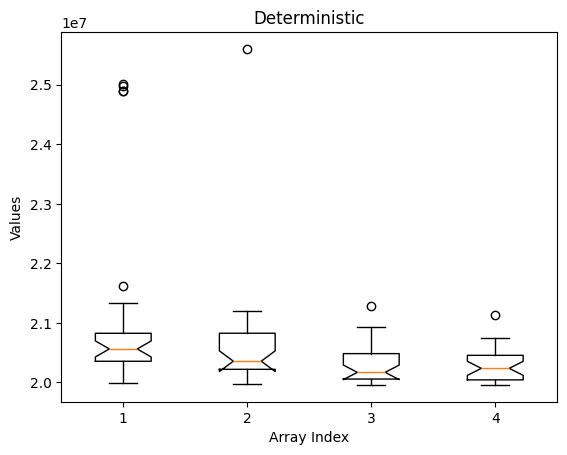

In [4]:
filename = 'FX_values_2_0.npz'
plot_boxplots(filename, "Deterministic")

In [6]:
# H0: there is no difference between your distribution and a normal distribution

print(shapiro(a0))
print(shapiro(b0))
print(shapiro(c0))
print(shapiro(d0))

# Based on the results, none of them are normally distributed.

ShapiroResult(statistic=0.605484314972138, pvalue=8.520097104134751e-08)
ShapiroResult(statistic=0.49247853707457145, pvalue=4.466245385253774e-09)
ShapiroResult(statistic=0.8432703563780186, pvalue=0.0004496885717848878)
ShapiroResult(statistic=0.9022110447440342, pvalue=0.009516482908822347)


In [7]:
# H0: the medians of the groups are equal

print(kruskal(a0, b0, c0, d0))

# since H0 is rejected, the medians are not equal.

KruskalResult(statistic=20.574172642301097, pvalue=0.0001290402736286622)


In [8]:
# H0: the distribution underlying the two samples is the same

print(f"a vs b: {mannwhitneyu(a0, b0, alternative='less')}")
print(f"a vs c: {mannwhitneyu(a0, c0, alternative='less')}")
print(f"a vs d: {mannwhitneyu(a0, d0, alternative='less')}")
print(f"b vs c: {mannwhitneyu(b0, c0, alternative='less')}")
print(f"b vs d: {mannwhitneyu(b0, d0, alternative='less')}")
print(f"c vs d: {mannwhitneyu(c0, d0, alternative='less')}")

a vs b: MannwhitneyuResult(statistic=515.0, pvalue=0.8335726542136359)
a vs c: MannwhitneyuResult(statistic=687.0, pvalue=0.9997770404396713)
a vs d: MannwhitneyuResult(statistic=699.0, pvalue=0.999887372931206)
b vs c: MannwhitneyuResult(statistic=643.5, pvalue=0.9979360474708523)
b vs d: MannwhitneyuResult(statistic=615.0, pvalue=0.9927945879106846)
c vs d: MannwhitneyuResult(statistic=442.5, pvalue=0.4587855137082125)


There is no significant difference between any pairs of groups (a, b, c, d)

## Stochastic

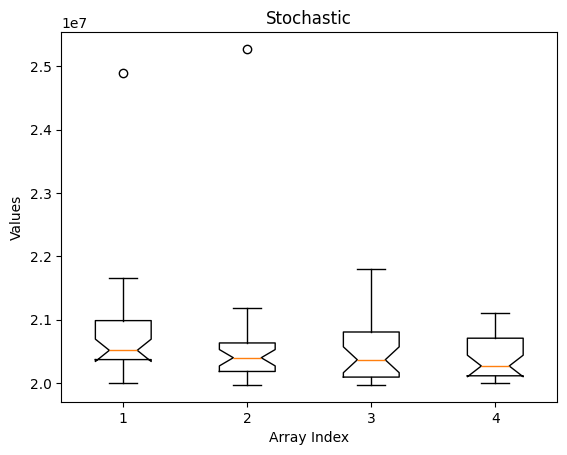

In [5]:
filename = 'FX_values_2_1.npz'
plot_boxplots(filename, "Stochastic")

In [9]:
# H0: there is no difference between your distribution and a normal distribution

print(shapiro(a1))
print(shapiro(b1))
print(shapiro(c1))
print(shapiro(d1))

# Based on the results, none of them are normally distributed.

ShapiroResult(statistic=0.6287468822039319, pvalue=1.6683342878662384e-07)
ShapiroResult(statistic=0.47034020105534946, pvalue=2.639519085355487e-09)
ShapiroResult(statistic=0.9017073049082004, pvalue=0.009248681013498355)
ShapiroResult(statistic=0.9048373889729943, pvalue=0.011051529848826626)


In [10]:
# H0: the medians of the groups are equal

print(kruskal(a1, b1, c1, d1))

# since H0 is not rejected, the medians are equal.

KruskalResult(statistic=5.983299244962824, pvalue=0.11242558621258349)


# Deterministic x Stochastic

In [11]:
# H0: the medians of the groups are equal

print(kruskal(a0, a1))
print(kruskal(b0, b1))
print(kruskal(c0, c1))
print(kruskal(d0, d1))

KruskalResult(statistic=0.04918032786883941, pvalue=0.824495751654794)
KruskalResult(statistic=0.6139890710382758, pvalue=0.43328979562188086)
KruskalResult(statistic=3.1216263280258496, pvalue=0.07725963849967657)
KruskalResult(statistic=2.8907907045671495, pvalue=0.0890871930157763)


There is no significant difference between any of the groups.